<a href="https://colab.research.google.com/github/MalavMDesai/GenAIAssignment/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [9]:
url="https://github.com/MalavMDesai/GenAIAssignment/raw/refs/heads/main/assignment4.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df

,Area,Bedrooms,Price
0,2097,3,382000.0
1,2211,4,472000.0
2,1662,3,344000.0
3,1897,5,444000.0
4,2095,2,367000.0
...,...,...,...
95,3090,3,595000.0
96,1287,4,352000.0
97,2588,4,521000.0
98,1123,2,233000.0


In [10]:
features = df[['Area', 'Bedrooms']]
target = df['Price']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=827
)

In [11]:
model = LinearRegression()
model.fit(scaler.transform(features_train), target_train)
target_pred = model.predict(scaler.transform(features_test))
print("MAE:", mean_absolute_error(target_test, target_pred))
print("MSE:", mean_squared_error(target_test, target_pred))
print("R2 Score:", r2_score(target_test, target_pred))
target_pred

MAE: 35172.297364956976
MSE: 1765345789.299621
R2 Score: 0.803992246797081


array([601715.45028418, 382907.33481263, 499689.04730565, 230445.16140628,
       613185.91871211, 396602.51901841, 533848.29986488, 468636.32689048,
       421474.23286337, 236647.06100856, 550943.95500345, 345673.60782727,
       488512.51766646, 426942.0036636 , 488313.31569188, 532924.69743449,
       588786.45259838, 546756.40451859, 450575.28325736, 568616.32303367])

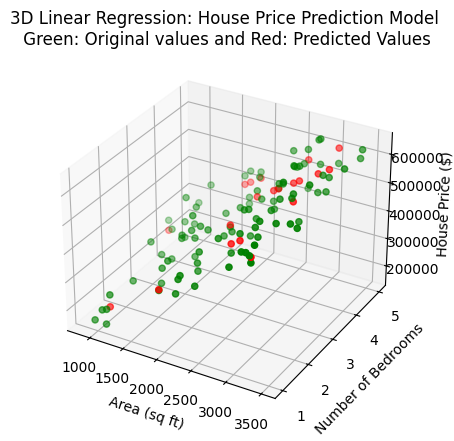

In [12]:
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
scat=ax.scatter(features_train['Area'],
                features_train['Bedrooms'],
                target_train,
                color='green')
scat=ax.scatter(features_test['Area'],
                features_test['Bedrooms'],
                target_test,
                color='green')
scat=ax.scatter(features_test['Area'],
                features_test['Bedrooms'],
                target_pred,
                color='red')

ax.set_title('3D Linear Regression: House Price Prediction Model\n Green: Original values and Red: Predicted Values')
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price ($)')

plt.show()